In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
!pip install torchviz
from torchviz import make_dot


# PyTorchのテンソル

## テンソルとfloat32はズッ友

In [2]:
# 0階テンソル（スカラー）
r0 = torch.tensor(1.0).float()
r0 = torch.tensor(1.0, dtype=torch.float32)
"""
テンソル変数の生成時には，必ずdtype（テンソル変数の要素のデータ型）を強制的にfloat32（32ビット浮動小数点型）に変換するように！
NumPy変数に対してこの処理を忘れると，dtypeがfloat64になり，「nn.Linear」などのライブラリを使う時にエラーになってしまう！
今でもそうなのかな？？
"""

print(type(r0)) # Python的な型
print(r0.dtype) # 中身のデータ型


<class 'torch.Tensor'>
torch.float32


## テンソルを純粋な数値として扱うdata属性

In [3]:
print(r0.data) # data属性により，テンソルを純粋な数値として扱う事ができる．

tensor(1.)


## np.ndarray -> torch.tensor

In [4]:
# 1階テンソル（ベクトル）

# 1階のndarray
r1_np = np.array([1, 2, 3, 4, 5], dtype=np.float32)
print(r1_np.shape)

# ndarrayからテンソルに変換
r1 = torch.tensor(r1_np, dtype=torch.float32)
print(r1.dtype)
print(r1.shape)
print(r1.data) # data属性で，テンソルを純粋な数値として扱う．
print()

r1_ref = torch.from_numpy(r1_np).float()
r1_np[0] = 3.14
print(r1_ref.data)

# torch.tensor(): 値渡し
# torch.from_numpy(): 参照渡し
# torch.numpy(): 参照渡し


(5,)
torch.float32
torch.Size([5])
tensor([1., 2., 3., 4., 5.])

tensor([3.1400, 2.0000, 3.0000, 4.0000, 5.0000])


In [5]:
# 2階テンソル（行列）

r2_np = np.array([
    [1, 5, 6],
    [4, 3, 2]
])
print(r2_np.shape)

r2 = torch.tensor(r2_np, dtype=torch.float32) # テンソル生成 => float32！
print(r2.dtype)
print(r2.shape)
print(r2.data) # data属性で，テンソルを純粋な数値として扱う．


(2, 3)
torch.float32
torch.Size([2, 3])
tensor([[1., 5., 6.],
        [4., 3., 2.]])


In [6]:
# 3階テンソル

torch.manual_seed(123) # 乱数シード固定

# shape=[3, 2, 2]の正規分布変数テンソルを作る．
r3 = torch.randn((3, 2, 2), dtype=torch.float32) # テンソル生成 => float32！

print(r3.dtype)
print(r3.shape)
print(r3.data) # テンソルを純粋な数値として扱うために，data属性．


torch.float32
torch.Size([3, 2, 2])
tensor([[[-0.1115,  0.1204],
         [-0.3696, -0.2404]],

        [[-1.1969,  0.2093],
         [-0.9724, -0.7550]],

        [[ 0.3239, -0.1085],
         [ 0.2103, -0.3908]]])


In [7]:
# 4階テンソル

# shape=[2, 3, 2, 2]のテンソルを1埋めで作る．
r4 = torch.ones((2, 3, 2, 2), dtype=torch.float32)

print(r4.dtype)
print(r4.shape)
print(r4.data) # data属性で，テンソルを純粋な数値として扱う事ができる．


torch.float32
torch.Size([2, 3, 2, 2])
tensor([[[[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]]],


        [[[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]]]])


## 整数値のテンソル作成
多値分類の損失関数では，整数型を使うことがある．

In [8]:
r1_np = np.array([1.1, 2.2, 3.3, 4.4, 5.5])
r1 = torch.tensor(r1_np, dtype=torch.float32)
print(r1.data)
print()

r5 = r1.long()
print(r5.dtype)
print(type(r5))
print(r5.data)


tensor([1.1000, 2.2000, 3.3000, 4.4000, 5.5000])

torch.int64
<class 'torch.Tensor'>
tensor([1, 2, 3, 4, 5])


## テンソルの階数を変換するview関数
np.reshape <=> torch.view

In [29]:
# 3階テンソル
torch.manual_seed(123) # 乱数シード固定
# shape=[3, 2, 2]の正規分布変数テンソルを作る．
r3 = torch.randn((3, 2, 2), dtype=torch.float32) # テンソル生成 => float32！
print(r3.dtype)
print(r3.shape)
print(r3.data) # テンソルを純粋な数値として扱うために，data属性．
print()

# 2階化
r6 = r3.view(3, -1) # 要素数に-1を指定すると，該当箇所が自動調整になる．
print(r6.shape)
print(r6.data)


torch.float32
torch.Size([3, 2, 2])
tensor([[[-0.1115,  0.1204],
         [-0.3696, -0.2404]],

        [[-1.1969,  0.2093],
         [-0.9724, -0.7550]],

        [[ 0.3239, -0.1085],
         [ 0.2103, -0.3908]]])

torch.Size([3, 4])
tensor([[-0.1115,  0.1204, -0.3696, -0.2404],
        [-1.1969,  0.2093, -0.9724, -0.7550],
        [ 0.3239, -0.1085,  0.2103, -0.3908]])


In [10]:
# 1階化
r7 = r3.view(-1) # -1で自動調整
print(r7.shape)
print(r7.data) # 純粋な数値として．


torch.Size([12])
tensor([-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724, -0.7550,
         0.3239, -0.1085,  0.2103, -0.3908])


In [11]:
# 1階化
r7 = r3.view(-1, -1) # 推論は1つまでしかできないよ．
print(r7.shape)
print(r7.data) # 純粋な数値として．


RuntimeError: only one dimension can be inferred

## テンソルのクラスとしての顔
テンソルはクラスなので，いくらかの属性やメソッドを持っている．

In [34]:
print("requires_grad:", r1.requires_grad) # 自動微分に関して．
print("device:", r1.device)


requires_grad: False
device: cpu


## テンソルのitem関数
スカラー（0階テンソル）に対しては，テンソルからPython本来のクラスの数値を取り出すことができる．

In [13]:
r0 = torch.tensor(1.0, dtype=torch.float32) # 0階テンソル
print(r0.shape)

item = r0.item()
print(type(item))
print(item)


torch.Size([])
<class 'float'>
1.0


0階テンソルでなくてもスカラーならOK．

In [14]:
t1 = torch.ones(1)
print(t1.shape) # 1階テンソルなのだが．
print(t1.item()) # スカラーなのでエラーにならない．


torch.Size([1])
1.0


## テンソルのmax関数
min, mean関数も同様に．

### 引数なし（クラス内関数呼び出し）

In [15]:
print(r2)
print(r2.max())


tensor([[1., 5., 6.],
        [4., 3., 2.]])
tensor(6.)


### 軸指定あり（torch.max関数）

In [16]:
print(r2, '\n')
print(torch.max(r2, 0), '\n') # 行インデックスを走査していく．1行がひとまとまりなので，最終的に1行が残る．
print(torch.max(r2, 1), '\n') # 列インデックスを走査していく．1列がひとまとまりなので，最終的に1列が残る．

print(torch.max(r2, 1)[1], '\n') # 最大値そのものよりインデックスが重要な場面もある．多値分類モデルでは，インデックスが予測結果ラベルそのものになる．


tensor([[1., 5., 6.],
        [4., 3., 2.]]) 

torch.return_types.max(
values=tensor([4., 5., 6.]),
indices=tensor([1, 0, 0])) 

torch.return_types.max(
values=tensor([6., 4.]),
indices=tensor([2, 0])) 

tensor([2, 0]) 



## テンソルからndarrayへの変換

In [17]:
print(r2.data)
r2_np = r2.data.numpy().copy() # 値渡し

print(type(r2_np))
print(r2_np)


tensor([[1., 5., 6.],
        [4., 3., 2.]])
<class 'numpy.ndarray'>
[[1. 5. 6.]
 [4. 3. 2.]]


# PyTorchの自動微分機能
(1) 勾配計算用変数の定義：requires_grad=True

(2) テンソル変数間で計算：計算グラフの自動生成

(3) 計算グラフの可視化：make_dot関数

(4) 勾配計算：backward関数

(5) 勾配値の取得：grad属性

(6) 勾配値の初期化：zero_関数

## 2次関数の勾配計算

### (1) 勾配計算用変数の定義：requires_grad=True

In [35]:
x_np = np.arange(-2, 2.1, 0.25) # np.arangeは，stopを含まない．
print(x_np, '\n')

x = torch.tensor(x_np, requires_grad=True, dtype=torch.float32) # float関数だと，xが勾配値計算可能なリーフノードではなくなる（？）らしい．
print(x)


[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.  ] 

tensor([-2.0000, -1.7500, -1.5000, -1.2500, -1.0000, -0.7500, -0.5000, -0.2500,
         0.0000,  0.2500,  0.5000,  0.7500,  1.0000,  1.2500,  1.5000,  1.7500,
         2.0000], requires_grad=True)


### (2) テンソル変数間で計算：計算グラフの自動生成

tensor([10.0000,  8.1250,  6.5000,  5.1250,  4.0000,  3.1250,  2.5000,  2.1250,
         2.0000,  2.1250,  2.5000,  3.1250,  4.0000,  5.1250,  6.5000,  8.1250,
        10.0000], grad_fn=<AddBackward0>)


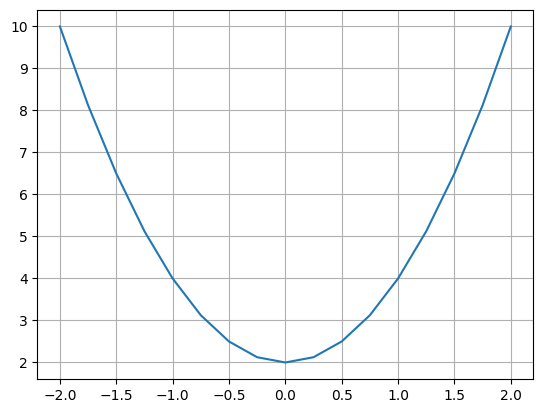

In [19]:
y = (2 * (x ** 2)) + 2
print(y)

plt.plot(x.data, y.data)
plt.grid()
plt.show()


In [20]:
# 勾配計算のためには，最終値はスカラーの必要があるため，ダミーでsum関数をかける．
z = y.sum()


### (3) 計算グラフの可視化：make_dot関数
NumPyでも全く同じ計算ができるが，NumPyでは計算過程が記録されない．値を計算しながら「計算グラフ」を自動的に記録する機能を「Define by Run」と呼ぶ．

この「計算グラフ」があればこそ，PyTorchはxを微小変化させた時のzの変化を調べられる．これが「backward関数による勾配計算」である．

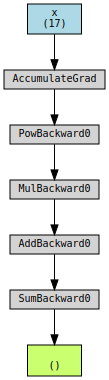

In [21]:
# from torchviz import make_dot
g = make_dot(z, params={'x': x})
display(g)


### (4) 勾配計算：backward関数

In [22]:
z.backward()


### (5) 勾配値の取得：grad属性
勾配計算の結果は，grad属性に保存される．

In [23]:
print(x.grad)

tensor([-8., -7., -6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,
         6.,  7.,  8.])


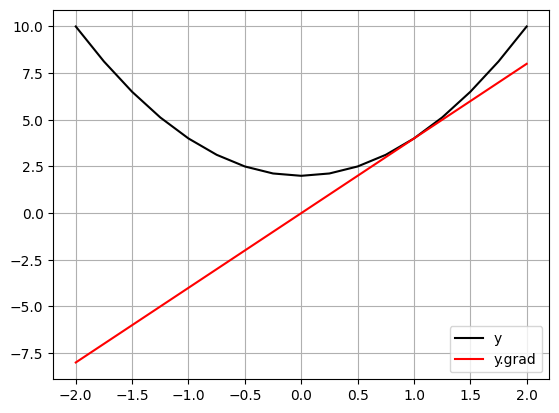

In [24]:
plt.plot(x.data, y.data, c='k', label='y')
plt.plot(x.data, x.grad.data, c='r', label='y.grad')
plt.legend()
plt.grid()
plt.show()


### (6) 勾配値の初期化：zero_関数

tensor([-16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,
          8.,  10.,  12.,  14.,  16.])


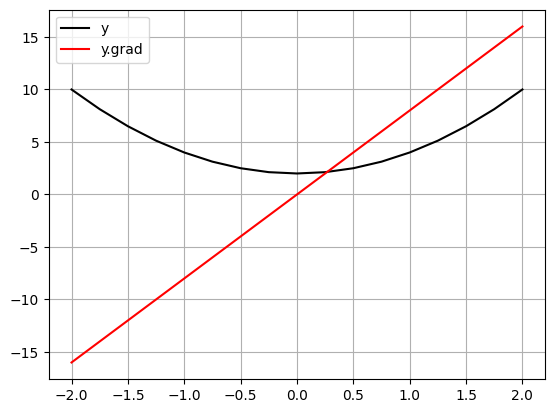

In [25]:
# 勾配の初期化をせずに2度目の勾配計算
y = (2 * (x ** 2)) + 2
z = y.sum()
z.backward()

# xの勾配確認
print(x.grad)

# おかしなグラフになる．
plt.plot(x.data, y.data, c='k', label='y')
plt.plot(x.data, x.grad.data, c='r', label='y.grad')
plt.legend()
plt.grid()
plt.show()


In [28]:
# きちんと勾配の初期化を行う．
x.grad.zero_()
print(x.grad)


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


## シグモイド関数の勾配計算

### (1) 勾配計算用変数の定義：requires_grad=True

In [51]:
x_np = np.arange(-2, 2.1, 0.25) # np.arangeは，stopを含まない．
print(x_np)

x = torch.tensor(x_np, requires_grad=True, dtype=torch.float32)
print(x)


[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.  ]
tensor([-2.0000, -1.7500, -1.5000, -1.2500, -1.0000, -0.7500, -0.5000, -0.2500,
         0.0000,  0.2500,  0.5000,  0.7500,  1.0000,  1.2500,  1.5000,  1.7500,
         2.0000], requires_grad=True)


### (2) テンソル変数間で計算：計算グラフの自動生成

In [52]:
sigmoid = torch.nn.Sigmoid()
y = sigmoid(x)


In [53]:
# 勾配計算のためには，最終値はスカラーの必要があるため，ダミーでsum関数をかける．
z = y.sum()


### (3) 計算グラフの可視化：make_dot関数

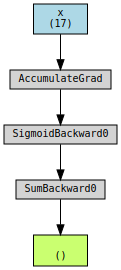

In [54]:
# from torchviz import make_dot
params = {'x': x} # ラベル付けをしているだけ
g = make_dot(z, params=params)
display(g)

# AccumulateGrad: x.gradに勾配を加算（蓄積）
# ...Backward0: 微分計算

# 緑の出力ノードから，青のリーフノードへ向けて逆伝搬していく．
# リーフノード：勾配値の計算が可能な変数


### (4) 勾配計算：backward関数

In [55]:
z.backward()


### (5) 勾配値の取得：grad属性

In [56]:
print(x.grad)


tensor([0.1050, 0.1261, 0.1491, 0.1731, 0.1966, 0.2179, 0.2350, 0.2461, 0.2500,
        0.2461, 0.2350, 0.2179, 0.1966, 0.1731, 0.1491, 0.1261, 0.1050])


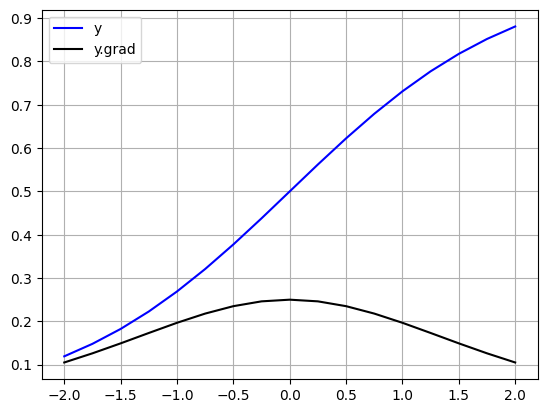

In [57]:
plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label='y.grad')
plt.legend()
plt.grid()
plt.show()


### (6) 勾配値の初期化：zero_関数

In [58]:
x.grad.zero_()
print(x.grad)


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
